# 文件: chart_28_1.py

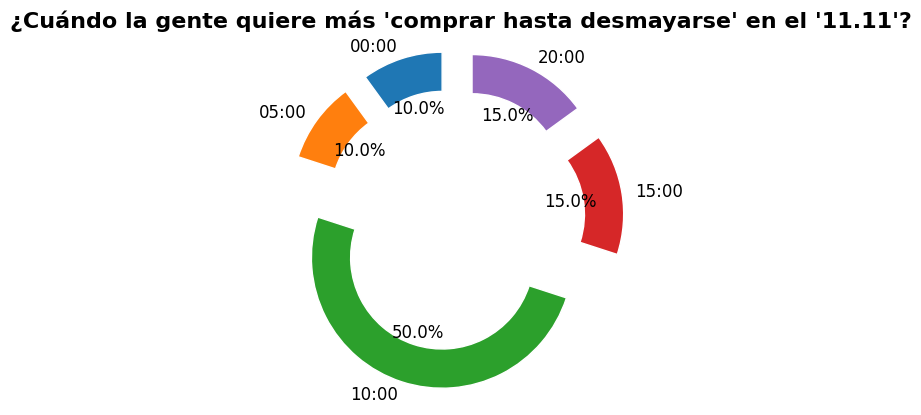

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Etiquetas de períodos de tiempo
etiquetas = ["00:00", "05:00", "10:00", "15:00", "20:00"]
# Datos de proporción simulados (pueden ser reemplazados según necesidades reales, los valores aquí son solo de demostración)
tamaños = [10, 10, 50, 15, 15]  
# Espacio en el gráfico de dona (para que la dona sea más obvia), aquí se establece uniformemente en 0.3, se puede ajustar
separacion = [0.3] * len(etiquetas)  

fig, ax = plt.subplots()

# Dibujar un gráfico de dona, wedgeprops controla el ancho y otros estilos de la dona
ax.pie(
    tamaños,
    explode=separacion,
    labels=etiquetas,
    autopct="%1.1f%%",  # Mostrar porcentaje
    startangle=90,      # Ángulo de inicio
    wedgeprops={"width": 0.3, "edgecolor": "white"},  # Ancho de la dona, color del borde
    textprops={"fontsize": 12}  # Tamaño de fuente del texto
)
ax.set_title("¿Cuándo la gente quiere más 'comprar hasta desmayarse' en el '11.11'?", fontsize=16, fontweight="bold")

# Mantener el gráfico de pastel circular (para evitar estiramiento y distorsión)
ax.axis("equal")  

plt.show()

# 文件: chart_28_2.py

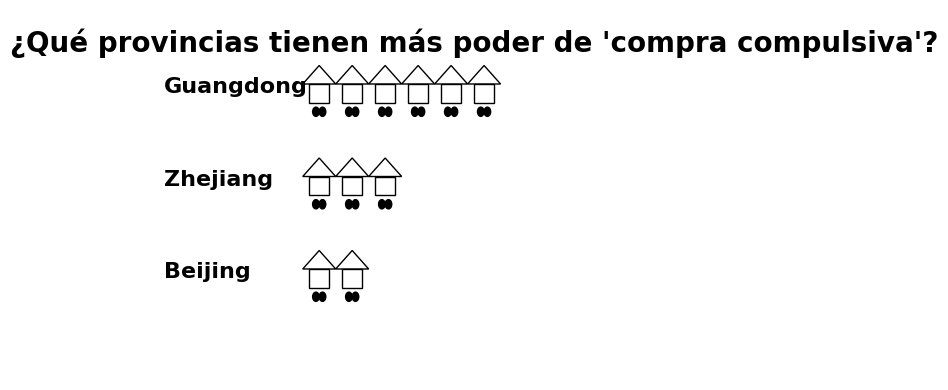

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Datos: Provincias y cantidades correspondientes de carritos de compra
data = {
    "Guangdong": 6,
    "Zhejiang": 3,
    "Beijing": 2
}
# Coordenadas de las provincias (posición en el eje y, controla la disposición vertical)
province_y = {
    "Guangdong": 2,
    "Zhejiang": 1,
    "Beijing": 0
}
# Tamaño básico del carrito de compra
cart_width = 0.3
cart_height = 0.2

# Crear un lienzo
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, 7)
ax.set_ylim(-1, 3)
ax.axis('off')  # Ocultar los ejes

# Dibujar el título - Modificado la coordenada x y la alineación
ax.text(
    3.5, 2.8, "¿Qué provincias tienen más poder de 'compra compulsiva'?", 
    fontsize=20, fontweight='bold',
    ha='center', va='top'
)

# Definir una función para dibujar un solo carrito de compra
def draw_cart(x, y):
    """
    Dibujar un icono simplificado de carrito de compra en la posición (x, y)
    """
    # Cesta del carrito de compra (rectángulo)
    cart_basket = patches.Rectangle(
        (x, y), cart_width, cart_height,
        facecolor='none', edgecolor='black'
    )
    ax.add_patch(cart_basket)
    # Asa del carrito de compra (simulada por un polígono)
    cart_handle = patches.Polygon(
        [[x - 0.1, y + cart_height],
         [x + cart_width + 0.1, y + cart_height],
         [x + cart_width / 2, y + cart_height + 0.2]],
        facecolor='none', edgecolor='black'
    )
    ax.add_patch(cart_handle)
    # Ruedas del carrito de compra (dos círculos pequeños)
    wheel1 = patches.Circle((x + 0.1, y - 0.1), 0.05, color='black')
    wheel2 = patches.Circle((x + 0.2, y - 0.1), 0.05, color='black')
    ax.add_patch(wheel1)
    ax.add_patch(wheel2)

# Iterar a través de los datos para dibujar nombres de provincias + carritos de compra
for province, count in data.items():
    # Dibujar el texto de la provincia
    ax.text(
        -1.2, province_y[province] + 0.1, 
        province, fontsize=16, fontweight='bold'
    )
    # Bucle para dibujar carritos de compra
    for i in range(count):
        cart_x = 1 + i * (cart_width + 0.2)  # Espaciado horizontal entre carritos de compra
        draw_cart(cart_x, province_y[province])

plt.tight_layout()
plt.show()

# 文件: chart_28_3.py

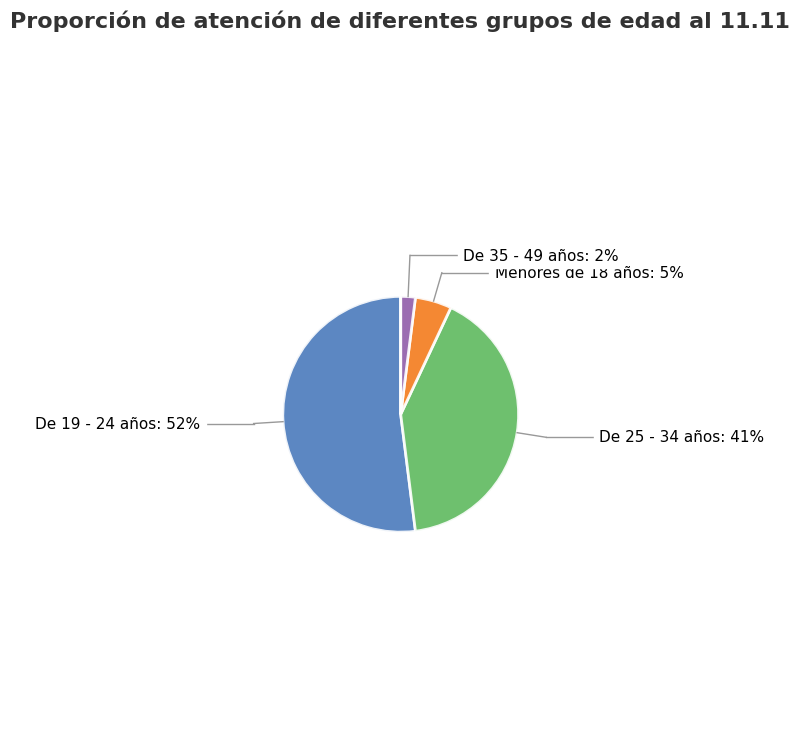

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Definición de datos
grupos_edad = ["De 19 - 24 años", "De 25 - 34 años", "Menores de 18 años", "De 35 - 49 años", "Mayores de 50 años"]
porcentajes_edad = [52, 41, 5, 2, 0]
colores_edad = ['#4A7ABC', '#5EB95E', '#F37B1D', '#905CA9', '#E5E5E5']

# Crear un lienzo
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

# Dibujar un gráfico circular mejorado
wedges, texts = ax.pie(
    porcentajes_edad,
    labels=None,
    autopct=None,
    startangle=90,
    colors=colores_edad,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    pctdistance=0.8,
)

# Agregar un efecto de sombra al gráfico circular
for w in wedges:
    w.set_alpha(0.9)
    w.set_zorder(1)

# Establecer el título
ax.set_title("Proporción de atención de diferentes grupos de edad al 11.11", fontsize=16, pad=25,
              fontweight='bold', color='#333333')
ax.axis('equal')  # Asegurar que el gráfico circular sea circular

# Optimizar el cálculo de la posición de las etiquetas, usando un estilo de línea diagonal + horizontal
posiciones_etiquetas = []

for i, (wedge, grupo, porcentaje) in enumerate(zip(wedges, grupos_edad, porcentajes_edad)):
    if porcentaje == 0:  # Saltar la parte del 0%
        continue

    # Obtener el ángulo del sector
    ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
    rad = np.deg2rad(ang)
    y = np.sin(rad)
    x = np.cos(rad)

    # Ajustar inteligentemente la distancia de la etiqueta
    angulo = wedge.theta2 - wedge.theta1
    radio_base = 1.25
    radio = radio_base + max(0, 0.3 - angulo / 180)

    # Calcular los puntos finales de la línea diagonal y la línea horizontal
    longitud_linea1 = 0.25
    longitud_linea2 = 0.4

    fin_linea1_x = x * (1 + longitud_linea1)
    fin_linea1_y = y * (1 + longitud_linea1)

    if x > 0:  # Etiquetas del lado derecho
        fin_linea2_x = fin_linea1_x + longitud_linea2
        fin_linea2_y = fin_linea1_y
    else:  # Etiquetas del lado izquierdo
        fin_linea2_x = fin_linea1_x - longitud_linea2
        fin_linea2_y = fin_linea1_y

    # Comprobar si hay una superposición con etiquetas existentes
    superposicion = False
    pos_etiqueta = (fin_linea2_x, fin_linea2_y)

    for pos in posiciones_etiquetas:
        dist = np.sqrt((pos_etiqueta[0] - pos[0]) ** 2 + (pos_etiqueta[1] - pos[1]) ** 2)
        if dist < 0.3:
            superposicion = True
            if x > 0:  # Mover la etiqueta del lado derecho hacia arriba
                fin_linea1_y += 0.1
                fin_linea2_y += 0.1
            else:  # Mover la etiqueta del lado izquierdo hacia abajo
                fin_linea1_y -= 0.1
                fin_linea2_y -= 0.1
            break

    posiciones_etiquetas.append(pos_etiqueta)

    # Dibujar la línea de conexión de dos segmentos
    ax.plot([x, fin_linea1_x], [y, fin_linea1_y], color='#999999', linestyle='-', linewidth=1)
    ax.plot([fin_linea1_x, fin_linea2_x], [fin_linea1_y, fin_linea2_y], color='#999999', linestyle='-', linewidth=1)

    # Agregar texto de la etiqueta
    if x > 0:
        ax.text(fin_linea2_x + 0.05, fin_linea2_y, f"{grupo}: {porcentaje}%",
                ha='left', va='center', fontsize=11, backgroundcolor='white')
    else:
        ax.text(fin_linea2_x - 0.05, fin_linea2_y, f"{grupo}: {porcentaje}%",
                ha='right', va='center', fontsize=11, backgroundcolor='white')

# Ajustar el diseño
plt.tight_layout(pad=3)

# Guardar el gráfico (opcional)
# plt.savefig('distribucion_edad.png', dpi=300, bbox_inches='tight')

# Mostrar el gráfico
plt.show()

# 文件: chart_28_4.py

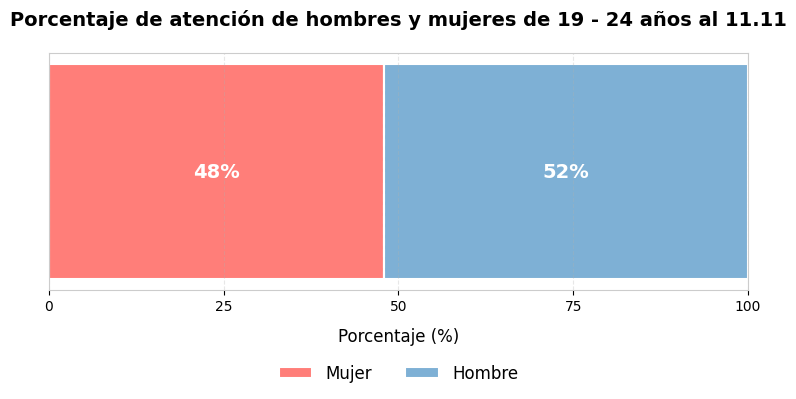

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Definición de datos
generos = ["Mujer", "Hombre"]
porcentajes_genero = [48, 52]
colores_genero = ['#FF7E79', '#7EB0D5']

# Crear un lienzo
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

# Dibujar un gráfico de barras segmentadas horizontales embellecido
altura_barra = 0.4
ax.barh(0, porcentajes_genero[0], color=colores_genero[0], 
         height=altura_barra, edgecolor='white', linewidth=1.5, label=generos[0])
ax.barh(0, porcentajes_genero[1], left=porcentajes_genero[0], color=colores_genero[1], 
         height=altura_barra, edgecolor='white', linewidth=1.5, label=generos[1])

# Agregar etiquetas de datos
ax.text(porcentajes_genero[0]/2, 0, f"{porcentajes_genero[0]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')
ax.text(porcentajes_genero[0] + porcentajes_genero[1]/2, 0, f"{porcentajes_genero[1]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')

# Establecer el estilo del gráfico de barras
ax.set_xlim(0, 100)
ax.set_yticks([])  # Eliminar el eje y
ax.set_xlabel("Porcentaje (%)", fontsize=12, labelpad=10)
ax.set_title("Porcentaje de atención de hombres y mujeres de 19 - 24 años al 11.11", fontsize=14, pad=20, fontweight='bold')

# Personalizar las marcas del eje x
ax.set_xticks([0, 25, 50, 75, 100])
ax.tick_params(axis='x', which='major', labelsize=10)

# Agregar una leyenda
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), 
           ncol=2, frameon=False, fontsize=12)

# Agregar líneas de cuadrícula
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Agregar un borde
for spine in ax.spines.values():
    spine.set_color('#cccccc')

# Agregar una línea diagonal en el límite - la línea de separación entre hombres y mujeres
divider_y = np.linspace(-altura_barra/2, altura_barra/2, 100)
divider_x = np.ones_like(divider_y) * porcentajes_genero[0]
ax.plot(divider_x, divider_y, color='white', linewidth=1.5, linestyle='--')

# Ajustar el diseño
plt.tight_layout(pad=3)

# Guardar el gráfico (opcional)
# plt.savefig('distribucion_genero.png', dpi=300, bbox_inches='tight')

# Mostrar el gráfico
plt.show()

# 文件: chart_28_5.py

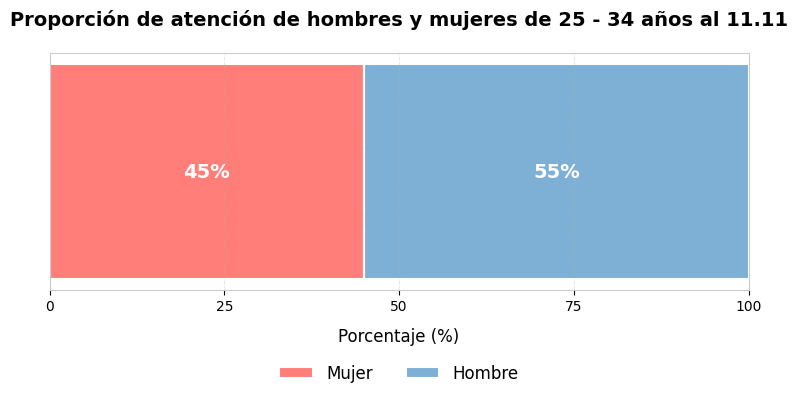

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Definición de datos
generos = ["Mujer", "Hombre"]
porcentajes_genero = [45, 55]
colores_genero = ['#FF7E79', '#7EB0D5']

# Crear un lienzo
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

# Dibujar un gráfico de barras segmentado horizontal embellecido
altura_barra = 0.4
ax.barh(0, porcentajes_genero[0], color=colores_genero[0], 
         height=altura_barra, edgecolor='white', linewidth=1.5, label=generos[0])
ax.barh(0, porcentajes_genero[1], left=porcentajes_genero[0], color=colores_genero[1], 
         height=altura_barra, edgecolor='white', linewidth=1.5, label=generos[1])

# Agregar etiquetas de datos
ax.text(porcentajes_genero[0]/2, 0, f"{porcentajes_genero[0]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')
ax.text(porcentajes_genero[0] + porcentajes_genero[1]/2, 0, f"{porcentajes_genero[1]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')

# Establecer el estilo del gráfico de barras
ax.set_xlim(0, 100)
ax.set_yticks([])  # Eliminar el eje y
ax.set_xlabel("Porcentaje (%)", fontsize=12, labelpad=10)
ax.set_title("Proporción de atención de hombres y mujeres de 25 - 34 años al 11.11", fontsize=14, pad=20, fontweight='bold')

# Personalizar las marcas del eje x
ax.set_xticks([0, 25, 50, 75, 100])
ax.tick_params(axis='x', which='major', labelsize=10)

# Agregar una leyenda
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), 
           ncol=2, frameon=False, fontsize=12)

# Agregar líneas de cuadrícula
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Agregar un borde
for spine in ax.spines.values():
    spine.set_color('#cccccc')

# Agregar una línea diagonal en el punto de división - la línea de separación entre hombres y mujeres
divider_y = np.linspace(-altura_barra/2, altura_barra/2, 100)
divider_x = np.ones_like(divider_y) * porcentajes_genero[0]
ax.plot(divider_x, divider_y, color='white', linewidth=1.5, linestyle='--')

# Ajustar el diseño
plt.tight_layout(pad=3)

# Guardar el gráfico (opcional)
# plt.savefig('distribucion_genero.png', dpi=300, bbox_inches='tight')

# Mostrar el gráfico
plt.show()